In [ ]:
# Step 1: Load libraries and dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('titanic_cleaned.csv')
numeric_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass', 'survived']
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
df.shape

(673, 14)

In [2]:
# Step 2: Re-run core stats

stats = df[numeric_cols].describe().T
stats['variance'] = df[numeric_cols].var()
stats

,count,mean,std,min,25%,50%,75%,max,variance
age,673.0,28.950223,13.604993,0.42,21.0000,28.0,36.00,80.0000,185.095830
fare,673.0,19.496087,14.809501,0.00,7.8958,13.0,26.55,71.2833,219.321310
sibsp,673.0,0.509658,1.022214,0.00,0.0000,0.0,1.00,8.0000,1.044921
parch,673.0,0.396731,0.837258,0.00,0.0000,0.0,0.00,6.0000,0.701001
pclass,673.0,2.427935,0.762549,1.00,2.0000,3.0,3.00,3.0000,0.581480
survived,673.0,0.365527,0.481936,0.00,0.0000,0.0,1.00,1.0000,0.232262


In [3]:
# Step 3: Re-run survival breakdowns 

print("Survival by sex:")
print(df.groupby('sex')['survived'].mean())
print()
print("Survival by class:")
print(df.groupby('class')['survived'].mean())
print()
print("Survival by class + sex:")
print(df.groupby(['class', 'sex'])['survived'].mean().unstack())

Survival by sex:
sex
female    0.678261
male      0.203160
Name: survived, dtype: float64

Survival by class:
class
First     0.522124
Second    0.522013
Third     0.259352
Name: survived, dtype: float64

Survival by class + sex:
sex       female      male
class                     
First   0.967742  0.353659
Second  0.916667  0.195402
Third   0.472441  0.160584


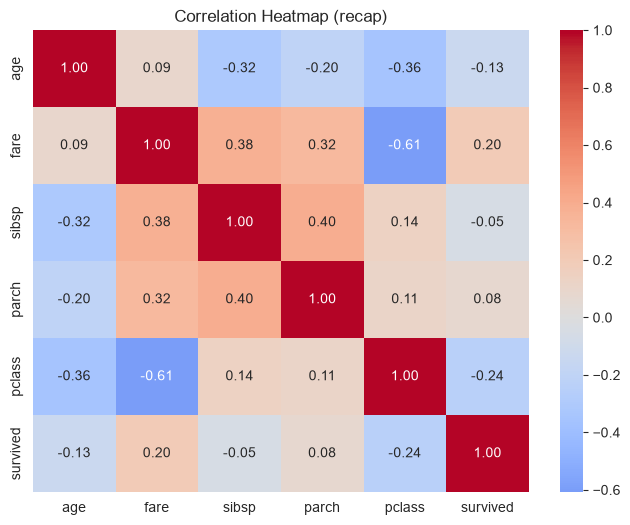

In [4]:
# Step 4: Re-run correlation matrix

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (recap)')
plt.show()


In [5]:
# Step 5: Anomaly check — fare = 0
# Free tickets look suspicious. Check who they belong to — could be crew, staff, or data entry issue.

free_fare = df[df['fare'] == 0]
print(f"Rows with fare = 0: {len(free_fare)}")
free_fare[['pclass', 'sex', 'age', 'survived']]

Rows with fare = 0: 9


,pclass,sex,age,survived
155,3,male,36.0,0
222,1,male,40.0,0
228,3,male,25.0,1
232,2,male,28.0,0
251,3,male,19.0,0
456,3,male,49.0,0
485,1,male,28.0,0
610,1,male,39.0,0
623,1,male,38.0,0


In [6]:
# Step 6: Anomaly check — extreme family size
# Large sibsp/parch values are rare — verify they're not data errors and see if they relate to survival.

large_family = df[(df['sibsp'] + df['parch']) >= 5]
print(f"Rows with family size >= 5: {len(large_family)}")
large_family[['pclass', 'sex', 'age', 'sibsp', 'parch', 'survived']]

Rows with family size >= 5: 38


,pclass,sex,age,sibsp,parch,survived
13,3,male,39.0,1,5,0
16,3,male,2.0,4,1,0
25,3,female,38.0,1,5,1
46,3,male,7.0,4,1,0
53,3,male,11.0,5,2,0
55,3,male,4.0,3,2,0
60,3,female,17.0,4,2,1
63,3,female,16.0,5,2,0
101,3,female,2.0,4,2,0
136,3,male,28.0,8,2,0


age_group
Child          0.562500
Teen           0.385965
Adult          0.362924
Middle-aged    0.304636
Senior         0.166667
Name: survived, dtype: float64


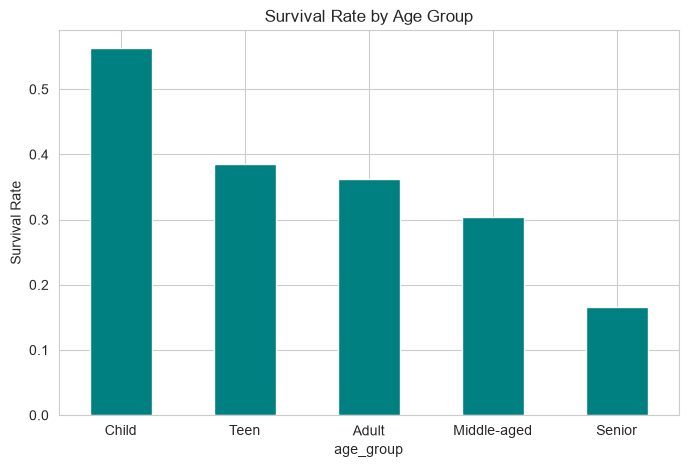

In [7]:
# Step 7: Age group breakdown
# Bin continuous age into groups — sometimes patterns are clearer in buckets than raw scatter.

df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 35, 60, 100],
                          labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])

survival_by_age_group = df.groupby('age_group')['survived'].mean()
print(survival_by_age_group)

survival_by_age_group.plot(kind='bar', color='teal')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

fare_quartile
Q1 (low)     0.213018
Q2           0.351190
Q3           0.450000
Q4 (high)    0.448718
Name: survived, dtype: float64


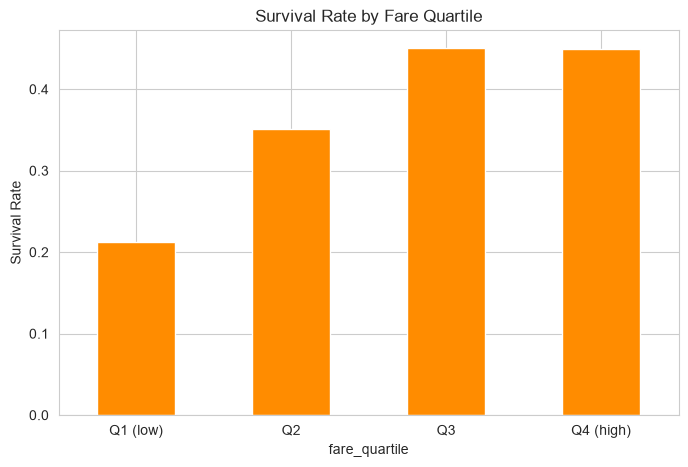

In [8]:
# Step 8: Fare quartile vs survival
# Bin fare into quartiles to check if survival advantage scales smoothly with wealth or jumps at a threshold.

df['fare_quartile'] = pd.qcut(df['fare'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

survival_by_fare_q = df.groupby('fare_quartile')['survived'].mean()
print(survival_by_fare_q)

survival_by_fare_q.plot(kind='bar', color='darkorange')
plt.title('Survival Rate by Fare Quartile')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

